In [2]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import datetime

city_file = "../germany_cities.csv"
city_df = pd.read_csv(city_file, sep=";")
city_df

,state,bezirk,city
0,baden-wuerttemberg,alb-donau-kreis,allmendingen
1,baden-wuerttemberg,alb-donau-kreis,altheim
2,baden-wuerttemberg,alb-donau-kreis,altheim-alb
3,baden-wuerttemberg,alb-donau-kreis,amstetten
4,baden-wuerttemberg,alb-donau-kreis,asselfingen
...,...,...,...
14001,schleswig-holstein,stormarn-kreis,trittau
14002,schleswig-holstein,stormarn-kreis,wesenberg
14003,schleswig-holstein,stormarn-kreis,westerau
14004,schleswig-holstein,stormarn-kreis,witzhave


In [47]:
base = "https://www.immobilienscout24.de/immobilienpreise/"
queries = ["wohnungspreise", "hauspreise", "mietspiegel", "mietpreise-haeuser"]
finalList = []

df_existing = pd.read_csv("germany_unit_prices.csv", sep=";")

def row_exists(val, df_existing):
    return((df_existing['state'] == val['state']) & (df_existing['city'] == val['bezirk']) & (df_existing['neighborhood'] == val['city'])).any()

for ix, val in city_df.iterrows():
    url = "/".join(val.values)

    if not row_exists(val, df_existing):

        for query in queries:

            r = requests.get(base + url + "/" + query)
            if r.status_code != 200:
                print(f"url cannot be found: {base + url + '/' + query}")
                break

            soup = BeautifulSoup(r.text, "lxml")

            try:
                price = soup.find("div" , {"data-testid" : "price-label"}).text
                price_min = soup.find("div" , {"data-testid" : "leastExpensive-label"}).text
                price_max = soup.find("div" , {"data-testid" : "mostExpensive-label"}).text
            except AttributeError:
                price = None
                price_min = None
                price_max = None

            finalList.append({"state" : val.state,
                "city" : val.bezirk,
                "district" : None,
                "neighborhood" : val.city.lower(),
                "type" : query,
                "price" : price,
                "price_min" : price_min,
                "price_max" : price_max})    

        if ix%50 == 0:
            print(f"Progress: {round(ix/14000*100,1)} -- querying: {base + url}")


In [48]:
df_unit_price = pd.DataFrame(finalList)
df_unit_price["price_clean"] = df_unit_price["price"].str.replace("Ø", "").str.replace(" €/m²", "").str.strip().str.replace(".", "").str.replace(",", ".").astype(float)
df_unit_price["price_min_clean"] = df_unit_price["price_min"].str.replace(" €/m²", "").str.strip().str.replace(".", "").str.replace(",", ".").astype(float)
df_unit_price["price_max_clean"] = df_unit_price["price_max"].str.replace(" €/m²", "").str.strip().str.replace(".", "").str.replace(",", ".").astype(float)

C:\Users\Ozan\AppData\Local\Temp\ipykernel_16248\2498285382.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df_unit_price["price_clean"] = df_unit_price["price"].str.replace("Ø", "").str.replace(" €/m²", "").str.strip().str.replace(".", "").str.replace(",", ".").astype(float)
C:\Users\Ozan\AppData\Local\Temp\ipykernel_16248\2498285382.py:3: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df_unit_price["price_min_clean"] = df_unit_price["price_min"].str.replace(" €/m²", "").str.strip().str.replace(".", "").str.replace(",", ".").astype(float)
C:\Users\Ozan\AppData\Local\Temp\ipykernel_16248\2498285382.py:4: FutureWarning: The default value of regex will change from True to Fa

In [49]:
df_unit_price.to_csv("germany_unit_prices_2.csv", sep=";", index=False, encoding="utf-8-sig")

In [72]:
df_existing = pd.read_csv("germany_unit_prices.csv", sep=";")
df_existing

,state,city,district,neighborhood,type,price,price_min,price_max,price_clean,price_min_clean,price_max_clean
0,baden-wuerttemberg,alb-donau-kreis,NaN,allmendingen,wohnungspreise,Ø 2.874 €/m²,2.713 €/m²,4.312 €/m²,2874.00,2713.00,4312.00
1,baden-wuerttemberg,alb-donau-kreis,NaN,allmendingen,hauspreise,Ø 3.120 €/m²,2.826 €/m²,3.886 €/m²,3120.00,2826.00,3886.00
2,baden-wuerttemberg,alb-donau-kreis,NaN,allmendingen,mietspiegel,"Ø 9,18 €/m²","8,82 €/m²","11,88 €/m²",9.18,8.82,11.88
3,baden-wuerttemberg,alb-donau-kreis,NaN,allmendingen,mietpreise-haeuser,"Ø 9,95 €/m²","9,48 €/m²","13,12 €/m²",9.95,9.48,13.12
4,baden-wuerttemberg,alb-donau-kreis,NaN,altheim,wohnungspreise,Ø 2.984 €/m²,2.973 €/m²,4.287 €/m²,2984.00,2973.00,4287.00
...,...,...,...,...,...,...,...,...,...,...,...
56016,schleswig-holstein,stormarn-kreis,NaN,witzhave,mietpreise-haeuser,"Ø 12,40 €/m²","12,30 €/m²","15,17 €/m²",12.40,12.30,15.17
56017,schleswig-holstein,stormarn-kreis,NaN,zarpen,wohnungspreise,Ø 3.199 €/m²,3.113 €/m²,4.527 €/m²,3199.00,3113.00,4527.00
56018,schleswig-holstein,stormarn-kreis,NaN,zarpen,hauspreise,Ø 2.920 €/m²,2.782 €/m²,3.612 €/m²,2920.00,2782.00,3612.00
56019,schleswig-holstein,stormarn-kreis,NaN,zarpen,mietspiegel,"Ø 9,12 €/m²","8,61 €/m²","13,42 €/m²",9.12,8.61,13.42


In [3]:
from sqlalchemy import create_engine, MetaData, inspect
# Create a SQLite database engine
engine = create_engine('sqlite:///germany_real_estate_database.db')  # echo=True will log SQL queries

# Define metadata
metadata = MetaData()
# Create an Inspector
inspector = inspect(engine)

In [4]:
df = pd.read_sql('SELECT * FROM main_table', engine)
df_unit = pd.read_sql('SELECT * FROM unit_price_table', engine)

In [4]:
def return_keyword(row):

    keyword_map = {
        ("Sale", "House"): "hauspreise",
        ("Sale", "Apartment"): "wohnungspreise",
        ("Rent", "House"): "mietpreise-haeuser",
        ("Rent", "Apartment"): "mietspiegel"
    }
    keyword = keyword_map.get((row["listing_type"], row["estate_type"]))
    return keyword


df_immo["type"] = df_immo.apply(return_keyword, axis=1)

In [102]:
df_pivot = df_unit.pivot_table(index='neighborhood', columns='type', values='price_clean')
df_unit

,state,city,district,neighborhood,type,price,price_min,price_max,price_clean,price_min_clean,price_max_clean
0,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,wohnungspreise,Ø 2.874 €/m²,2.713 €/m²,4.312 €/m²,2874.00,2713.00,4312.00
1,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,hauspreise,Ø 3.120 €/m²,2.826 €/m²,3.886 €/m²,3120.00,2826.00,3886.00
2,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietspiegel,"Ø 9,18 €/m²","8,82 €/m²","11,88 €/m²",9.18,8.82,11.88
3,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietpreise-haeuser,"Ø 9,95 €/m²","9,48 €/m²","13,12 €/m²",9.95,9.48,13.12
4,baden-wuerttemberg,alb-donau-kreis,None,altheim,wohnungspreise,Ø 2.984 €/m²,2.973 €/m²,4.287 €/m²,2984.00,2973.00,4287.00
...,...,...,...,...,...,...,...,...,...,...,...
56016,schleswig-holstein,stormarn-kreis,None,witzhave,mietpreise-haeuser,"Ø 12,40 €/m²","12,30 €/m²","15,17 €/m²",12.40,12.30,15.17
56017,schleswig-holstein,stormarn-kreis,None,zarpen,wohnungspreise,Ø 3.199 €/m²,3.113 €/m²,4.527 €/m²,3199.00,3113.00,4527.00
56018,schleswig-holstein,stormarn-kreis,None,zarpen,hauspreise,Ø 2.920 €/m²,2.782 €/m²,3.612 €/m²,2920.00,2782.00,3612.00
56019,schleswig-holstein,stormarn-kreis,None,zarpen,mietspiegel,"Ø 9,12 €/m²","8,61 €/m²","13,42 €/m²",9.12,8.61,13.42


In [18]:
def return_city_keyword(row):
    neighborhood = row["district"].strip().lower().replace(" ", "-").replace("ö","oe").replace("ü","ue").replace("ß","ss")
    city = row["city"].strip().lower().replace(" ", "-").replace("ö","oe").replace("ü","ue").replace("ß","ss")
    type = row["type"]
    try:
        return df_pivot.loc[neighborhood, type]
    except KeyError:
        try:
            return df_pivot.loc[city, type]
        except KeyError:
            return None
# df_immo["ref_price"] = df_immo.apply(return_city_keyword, axis=1).round()

In [123]:
df_immo.groupby(["city", "estate_type"])["return_in_years"] \
    .agg(["count", "mean"]) \
    .query("count > 20") \
    .sort_values(by="mean") \
    .round(2)["mean"] \
    .unstack() \
    .plot(kind="bar", figsize=(15,5))

estate_type,apartment,house
city,,
Duisburg,18.99,23.67
Hamm,NaN,20.20
Essen,24.08,21.17
Marl,NaN,23.43
Paderborn,NaN,27.35
Dortmund,NaN,27.61
Köln,27.74,30.90
Nürnberg,30.92,29.70
Aachen,32.61,29.87


<AxesSubplot: ylabel='city'>

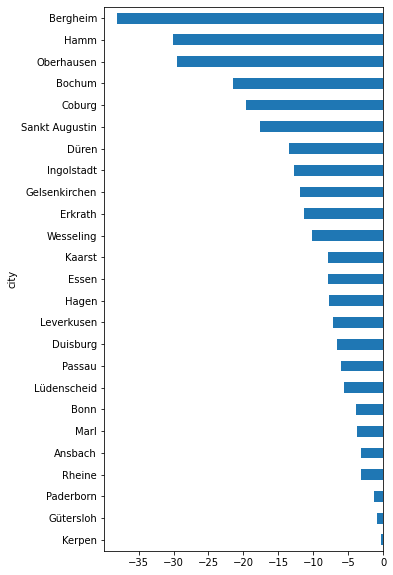

In [117]:
df_immo.groupby(["city"])["sale_ratio"] \
    .agg(["count", "mean"]) \
    .query("count > 15") \
    .sort_values(by="mean", ascending=False) \
    .query("mean <= 0") \
    .round(2)["mean"] \
    .plot(kind="barh", figsize=(5,10))

In [70]:
len(df_immo.city.unique().tolist())

775

In [72]:
df_immo.city.str.split("/").str[0].str.split("(").str[0].str.strip().str.capitalize().unique().tolist()

['Münster',
 'Gelsenkirchen',
 'Emsdetten',
 'Würselen',
 'Köln',
 'Wiehl',
 'Wassenberg',
 'Düsseldorf',
 'Marl',
 'Halle',
 'Dortmund',
 'Tönisvorst',
 'Mönchengladbach',
 'Korschenbroich',
 'Minden',
 'Langenfeld',
 'Winterberg',
 'Hagen',
 'Warburg',
 'Euskirchen',
 'Bocholt',
 'Kürten',
 'Bielefeld',
 'Neunkirchen-seelscheid',
 'Legden',
 'Bad salzuflen',
 'Wülfrath',
 'Erftstadt-liblar',
 'Bornheim',
 'Rhede',
 'Krefeld',
 'Schlangen',
 'Aachen',
 'Essen',
 'Moers',
 'Hüllhorst',
 'Rheda-wiedenbrück',
 'Rheine',
 'Borken',
 'Elsdorf',
 'Düren',
 'Langerwehe',
 'Hamm',
 'Kaarst',
 'Merzenich',
 'Wetter',
 'Neuss',
 'Pulheim',
 'Detmold',
 'Waltrop',
 'Erftstadt',
 'Kirchhundem',
 'Horstmar',
 'Herten',
 'Barntrup',
 'Leopoldshöhe',
 'Greven',
 'Übach-palenberg',
 'Meckenheim',
 'Selm',
 'Gladbeck',
 'Königswinter',
 'Selfkant',
 'Remscheid',
 'Mettmann',
 'Wachtendonk',
 'Drensteinfurt-rinkerode',
 'Plettenberg',
 'Kerpen',
 'Meerbusch',
 'Duisburg',
 'Bochum',
 'Herne',
 'Jülich'

In [75]:
df_unit.

,state,city,district,neighborhood,type,price,price_min,price_max,price_clean,price_min_clean,price_max_clean
0,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,wohnungspreise,Ø 2.874 €/m²,2.713 €/m²,4.312 €/m²,2874.00,2713.00,4312.00
1,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,hauspreise,Ø 3.120 €/m²,2.826 €/m²,3.886 €/m²,3120.00,2826.00,3886.00
2,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietspiegel,"Ø 9,18 €/m²","8,82 €/m²","11,88 €/m²",9.18,8.82,11.88
3,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietpreise-haeuser,"Ø 9,95 €/m²","9,48 €/m²","13,12 €/m²",9.95,9.48,13.12
4,baden-wuerttemberg,alb-donau-kreis,None,altheim,wohnungspreise,Ø 2.984 €/m²,2.973 €/m²,4.287 €/m²,2984.00,2973.00,4287.00
...,...,...,...,...,...,...,...,...,...,...,...
56016,schleswig-holstein,stormarn-kreis,None,witzhave,mietpreise-haeuser,"Ø 12,40 €/m²","12,30 €/m²","15,17 €/m²",12.40,12.30,15.17
56017,schleswig-holstein,stormarn-kreis,None,zarpen,wohnungspreise,Ø 3.199 €/m²,3.113 €/m²,4.527 €/m²,3199.00,3113.00,4527.00
56018,schleswig-holstein,stormarn-kreis,None,zarpen,hauspreise,Ø 2.920 €/m²,2.782 €/m²,3.612 €/m²,2920.00,2782.00,3612.00
56019,schleswig-holstein,stormarn-kreis,None,zarpen,mietspiegel,"Ø 9,12 €/m²","8,61 €/m²","13,42 €/m²",9.12,8.61,13.42


In [124]:
grunderwerb = 6.5
notar = 1.5
grundbuch = 0.5
provision = 3.75
price = 500000
eigen = 25
debt = price*(1 + (grunderwerb+notar+grundbuch+provision)/100)*(1 - eigen/100)

zinsen = 3.1
tilgung = 4.0

In [2]:
# Parameters
grunderwerb = 6.5  # Land transfer tax
notar = 1.5        # Notary fees
grundbuch = 0.5    # Land registration fees
provision = 3.75   # Broker commission
price = 500000     # Purchase price
eigen = 25         # Down payment percentage

zinsen = 3.1       # Interest rate
tilgung = 4.0      # Repayment rate
years = 10         # Duration of the loan in years

# Total cost including additional fees
total_cost = price * (1 + (grunderwerb + notar + grundbuch + provision) / 100)

# Initial loan amount after down payment
loan_amount = total_cost * (1 - eigen / 100)

# Annual interest and repayment
annual_interest = loan_amount * zinsen / 100
annuitat =  loan_amount * (zinsen + tilgung) / 100

# Amortization schedule over 10 years
remaining_debt = loan_amount
amortization_schedule = []

for year in range(1, years + 1):
    interest_payment = remaining_debt * zinsen / 100
    principal_payment = annuitat - interest_payment
    total_payment = interest_payment + principal_payment
    remaining_debt -= principal_payment
    
    amortization_schedule.append({
        "Year": year,
        "Interest Payment": round(interest_payment, 2),
        "Principal Payment": round(principal_payment, 2),
        "Total Payment": round(total_payment, 2),
        "Remaining Debt": round(remaining_debt, 2)
    })

# Display the amortization schedule
import pandas as pd

df_amortization = pd.DataFrame(amortization_schedule)
print(df_amortization)


   Year  Interest Payment  Principal Payment  Total Payment  Remaining Debt
0     1          13049.06           16837.50       29886.56       404100.00
1     2          12527.10           17359.46       29886.56       386740.54
2     3          11988.96           17897.61       29886.56       368842.93
3     4          11434.13           18452.43       29886.56       350390.50
4     5          10862.11           19024.46       29886.56       331366.04
5     6          10272.35           19614.22       29886.56       311751.83
6     7           9664.31           20222.26       29886.56       291529.57
7     8           9037.42           20849.15       29886.56       270680.43
8     9           8391.09           21495.47       29886.56       249184.96
9    10           7724.73           22161.83       29886.56       227023.13


In [10]:
df_amortization["Interest Payment"].sum().round()
    

104951.0

In [6]:
df_amortization.iloc[-1,-1]

227023.13

In [150]:
def format_thousands(x):
    if isinstance(x, (int, float)):
        return '{:,.0f} €'.format(x)
    return x
df1[["a", "za", "ta", "rs", "m"]] = df1[["a", "za", "ta", "rs", "m"]].applymap(format_thousands)
df1

,z,t,a,za,ta,rs,m
0,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
1,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
2,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
3,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
4,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
5,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
6,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
7,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
8,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"
9,3.1,4.0,"29,887 €","1,304,906 €","1,683,750 €","420,938 €","2,491 €"


In [6]:
df.groupby(["city"])["sale_ratio"] \
        .agg(["count", "mean"]) \
        .query("count > 20") \
        .sort_values(by="mean", ascending=False) \
        .query("mean <= 0") \
        .round(2)

,count,mean
city,,
Schweinfurt,21,0.00
Gütersloh,33,-0.76
Bonn,34,-0.91
Erftstadt,26,-1.50
Marl,34,-2.12
Essen,104,-2.75
Duisburg,112,-3.56
,2224,-4.26
Wesseling,44,-4.32


<AxesSubplot: xlabel='city'>

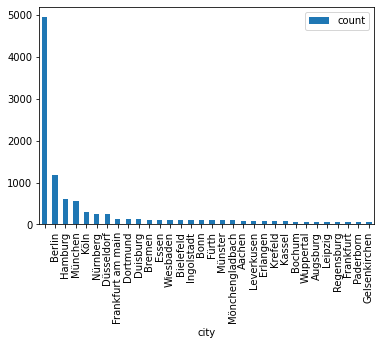

In [7]:
df.groupby(["city"])["city"] \
        .agg(["count"]) \
        .query("count > 50") \
        .sort_values(by="count", ascending=False) \
        .round(2) \
        .plot(kind="bar")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27128 entries, 0 to 27127
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              27128 non-null  object 
 1   makler           27128 non-null  object 
 2   address          27128 non-null  object 
 3   image            27124 non-null  object 
 4   title            27128 non-null  object 
 5   city             27128 non-null  object 
 6   district         27128 non-null  object 
 7   postal_code      27125 non-null  float64
 8   listing_type     27128 non-null  object 
 9   estate_type      27128 non-null  object 
 10  type             27082 non-null  object 
 11  price            27028 non-null  float64
 12  room             27028 non-null  float64
 13  area             27028 non-null  float64
 14  price_per_m2     27028 non-null  float64
 15  ref_price        19566 non-null  float64
 16  sale_ratio       19516 non-null  float64
 17  ref_rent_pri

In [14]:
bins = [60,90,120,150,180,210]
df_immo['category'] = pd.cut(df_immo['area'], bins)

In [52]:
df_immo.groupby("category")["return_in_years"].agg(["mean"]).index

CategoricalIndex([(60, 90], (90, 120], (120, 150], (150, 180], (180, 210]], categories=[(60, 90], (90, 120], (120, 150], (150, 180], (180, 210]], ordered=True, dtype='category', name='category')

<AxesSubplot: xlabel='room'>

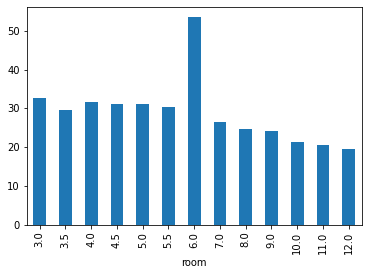

In [37]:
df_immo.groupby("room")["return_in_years"].agg(["count", "mean"]).query("count > 95").sort_index()["mean"].plot(kind="bar")

<AxesSubplot: xlabel='room'>

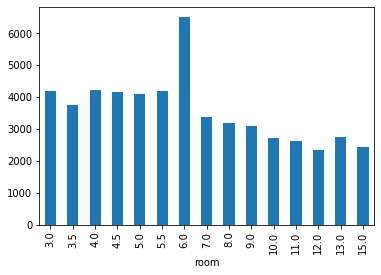

In [41]:
df_immo.groupby("room")["price_per_m2"].agg(["count", "mean"]).query("count > 100").sort_index()["mean"].plot(kind="bar")

<AxesSubplot: xlabel='estate_type'>

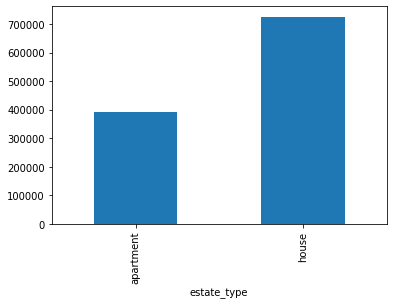

In [49]:
df_immo.groupby("estate_type")["price"].agg(["mean"])["mean"].plot(kind="bar")


In [53]:
df_immo.estate_type.unique().tolist()

['apartment', 'house']

In [13]:
import requests
url = "https://www.funda.nl/en/zoeken/koop?selected_area=%5B%22den-haag%22%5D&sort=%22price_up%22&price=%22100000-%22&object_type=%5B%22house%22%5D"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9',
'Accept-Language': 'en-US,en;q=0.9'}
r = requests.get(url, headers=headers)

In [ ]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(r.text, "lxml")

divs = soup.findAll("div" , {"data-test-id" : "search-result-item"})
for div in divs:
    print(div.text.strip())

<AxesSubplot: xlabel='city'>

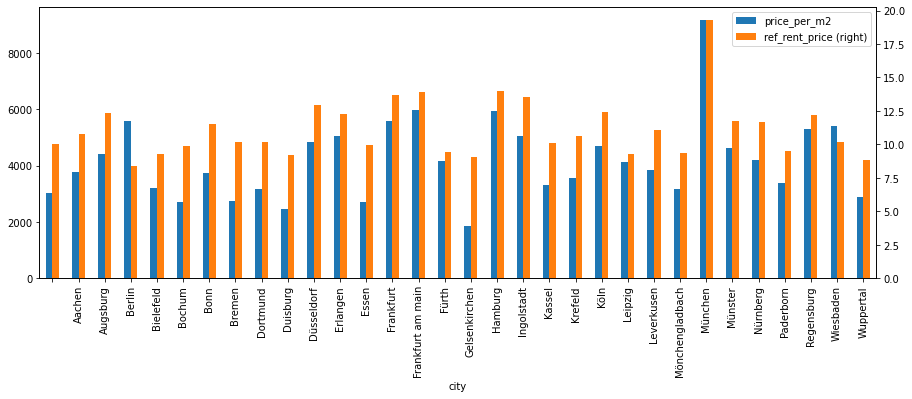

In [9]:
most_popular_cities = df.city.value_counts()[df.city.value_counts() > 50].index.tolist()

df[df.city.isin(most_popular_cities)].groupby(["city"])[["price_per_m2", "ref_rent_price"]] \
    .mean() \
    .plot(kind="bar", secondary_y=["ref_rent_price"], figsize=(15,5))

In [6]:
df[df.city.isin(most_popular_cities)].groupby(["city"])[["price_per_m2", "ref_rent_price"]] \
    .mean()

,price_per_m2,ref_rent_price
city,,
,3044.173754,10.070949
Aachen,3775.790123,10.753333
Augsburg,4412.444444,12.365333
Berlin,5583.193991,8.377877
Bielefeld,3207.500000,9.317143
Bochum,2715.641791,9.870392
Bonn,3752.843750,11.541429
Bremen,2756.468468,10.220333
Dortmund,3184.650000,10.211311


In [7]:
df[df.city.isin(most_popular_cities)].groupby(["city", "estate_type"])["return_in_years"] \
          .agg(["count", "mean"]) \
          .query("count > 30") \
          .sort_values(by="mean") \
          .round(2)["mean"] \
          .unstack()

estate_type,apartment,house
city,,
Essen,24.74,20.15
Duisburg,21.28,22.95
Bremen,24.52,22.40
,28.69,24.56
Dortmund,NaN,27.64
Paderborn,NaN,27.80
Aachen,32.09,27.95
Düsseldorf,32.30,29.42
Köln,31.22,29.58


In [101]:
selected_city = "Essen"

df1 = df.query("city == @selected_city")

In [102]:
df_postal_latlon = pd.read_csv("plz_geocoord.csv", sep=",")

def get_lat_lon(postal):
    try:
        return df_postal_latlon.query("postal == @postal")[["lat", "lng"]].values.tolist()[0]
    except IndexError:
        return [None,None]

df1['lat'], df1['lon'] = zip(*df1.postal_code.apply(get_lat_lon))

C:\Users\Ozan\AppData\Local\Temp\ipykernel_20776\2125832318.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['lat'], df1['lon'] = zip(*df1.postal_code.apply(get_lat_lon))


In [117]:
df1.dropna(subset=["lat"])

,url,makler,address,image,title,city,district,postal_code,listing_type,estate_type,...,price_per_m2,ref_price,sale_ratio,ref_rent_price,return_in_years,yield_ratio,source,query_date,lat,lon
138,https://www.immowelt.de/expose/4bdbf19d-89e5-4...,PlanetHome Group GmbH,"Bergerhausen, Essen (45136)",https://mms.immowelt.de/3/2/8/0/32800410-5567-...,Wohnung zum Kauf,Essen,Bergerhausen,45136.0,sale,apartment,...,3851.0,2821.0,37.0,9.01,35.6,2.81,immowelt,2024-10-13,51.435644,7.035561
298,https://www.immowelt.de/expose/84dad690-cf17-4...,McMakler GmbH,"Kupferdreh, Essen (45257)",https://mms.immowelt.de/0/6/9/1/06910a38-7c35-...,Wohnung zum Kauf,Essen,Kupferdreh,45257.0,sale,apartment,...,2975.0,2803.0,6.0,8.95,27.7,3.61,immowelt,2024-10-13,51.383040,7.081856
472,https://www.immowelt.de/expose/00700be4-7566-4...,ohne-makler.net - Immobilien selbst vermarkten,"Bedingrade, Essen (45359)",https://mms.immowelt.de/3/0/3/a/303a5f4d-f1c8-...,Mehrfamilienhaus zum Kauf,Essen,Bedingrade,45359.0,sale,house,...,1596.0,3613.0,-56.0,12.77,10.4,9.62,immowelt,2024-10-13,51.465929,6.925970
576,https://www.immowelt.de/expose/cbdb8a00-366e-4...,Vonovia SE-Selbstständiger Vertriebspartner,"Nienhuser Busch 47, Katernberg, Essen (45327)",https://mms.immowelt.de/2/8/f/5/28f501de-df29-...,Wohnung zum Kauf,Essen,Katernberg,45327.0,sale,apartment,...,1765.0,1951.0,-10.0,7.57,19.4,5.15,immowelt,2024-10-13,51.498829,7.038151
586,https://www.immowelt.de/expose/7d55add0-64f0-4...,Vonovia SE-Selbstständiger Vertriebspartner,"Drostenbusch 119, Schonnebeck, Essen (45309)",https://mms.immowelt.de/a/a/6/c/aa6c6b2f-e705-...,Wohnung zum Kauf,Essen,Schonnebeck,45309.0,sale,apartment,...,2183.0,2150.0,2.0,7.47,24.4,4.10,immowelt,2024-10-13,51.475635,7.072543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20727,https://www.immowelt.de/expose/5f589620-d1f2-4...,Milkereit Immobilien,"Schliepersberg 19a, Kupferdreh, Essen (45257)",https://mms.immowelt.de/d/e/c/d/decdfd6e-1248-...,Doppelhaushälfte zum Kauf,Essen,Kupferdreh,45257.0,sale,house,...,3250.0,3810.0,15.0,12.91,21.0,4.76,immowelt,2024-10-15,51.383040,7.081856
20740,https://www.immowelt.de/expose/96778811-eca4-4...,ohne-makler.net - Immobilien selbst vermarkten,"Ostviertel, Essen (45127)",https://mms.immowelt.de/7/6/5/1/76517fbb-521d-...,Mehrfamilienhaus zum Kauf,Essen,Ostviertel,45127.0,sale,house,...,2804.0,2885.0,3.0,11.68,20.0,5.00,immowelt,2024-10-15,51.455619,7.010454
20844,https://www.immowelt.de/expose/fa7b3828-fa9d-4...,Hirschmann Immobilien GmbH,"Rüttenscheid, Essen (45130)",https://mms.immowelt.de/c/a/2/7/ca27c9f3-afe1-...,Wohnung zum Kauf,Essen,Rüttenscheid,45130.0,sale,apartment,...,2937.0,3583.0,18.0,9.92,24.7,4.05,immowelt,2024-10-15,51.438429,7.011142
20928,https://www.immowelt.de/expose/65b37b81-697c-4...,Hirschmann Immobilien GmbH,"Frohnhausen, Essen (45144)",https://mms.immowelt.de/f/7/6/b/f76bb4b9-5947-...,Wohnung zum Kauf,Essen,Frohnhausen,45144.0,sale,apartment,...,1896.0,2137.0,11.0,8.07,19.6,5.10,immowelt,2024-10-15,51.451585,6.967573


In [ ]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[51, 8], zoom_start=9)

marker_cluster = MarkerCluster().add_to(m)

# df['lat'], df['lon'] = zip(*df.postal_code.apply(get_lat_lon))

for ix,val in df.dropna().iterrows():
    # html_content = f"<a href={val.url}>{val.title} - {val.price}</a>"
    html_content = val.to_frame().to_html(classes="table table-striped table-hover table-condensed table-responsive")
    folium.Marker(
        location=[val["lat"], val["lon"]],
        popup=html_content,
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(marker_cluster)

m

In [121]:
df[df.city.isin(most_popular_cities)].groupby(["city", "estate_type"])["return_in_years"] \
          .agg(["count", "mean"]) \
          .query("count > 30") \
          .sort_values(by="mean") \
          .round(2)["mean"] \
          .unstack()

estate_type,apartment,house
city,,
Essen,24.74,20.15
Duisburg,21.28,22.95
Bremen,24.52,22.40
,28.69,24.56
Dortmund,NaN,27.64
Paderborn,NaN,27.80
Aachen,32.09,27.95
Düsseldorf,32.30,29.42
Köln,31.22,29.58


In [40]:
dfTest = df.groupby(["district","postal_code"])["price_per_m2"] \
    .agg(["mean", "count"]) \
    .round().query("count > 10 ") \
    .reset_index().iloc[1:]
dfTest

,district,postal_code,mean,count
1,,24354.0,3299.0,15
2,,24850.0,2789.0,12
3,,24878.0,2800.0,11
4,,24888.0,2942.0,13
5,,25788.0,2469.0,11
...,...,...,...,...
384,Wüllen,48683.0,3689.0,19
385,Würselen,52146.0,3005.0,18
386,Zehlendorf,14165.0,7423.0,13
387,Überlingen,88662.0,6479.0,12


In [24]:
df_zip = pd.read_json("nrw-postleitzahlen.json")
df_zip

,name,plz_name,plz_name_long,geometry,plz_code,krs_code,lan_name,lan_code,krs_name,geo_point_2d
0,47551,Bedburg-Hau,47551 Bedburg-Hau,"{'type': 'Feature', 'geometry': {'coordinates'...",47551,5154,Nordrhein-Westfalen,5,Kreis Kleve,"{'lon': 6.20695861505, 'lat': 51.7581345416}"
1,52477,Alsdorf,52477 Alsdorf,"{'type': 'Feature', 'geometry': {'coordinates'...",52477,5334,Nordrhein-Westfalen,5,Kreis Städteregion Aachen,"{'lon': 6.17550818828, 'lat': 50.86861665}"
2,52159,Roetgen,52159 Roetgen,"{'type': 'Feature', 'geometry': {'coordinates'...",52159,5334,Nordrhein-Westfalen,5,Kreis Städteregion Aachen,"{'lon': 6.18337503317, 'lat': 50.6583845345}"
3,52156,Monschau,52156 Monschau,"{'type': 'Feature', 'geometry': {'coordinates'...",52156,5334,Nordrhein-Westfalen,5,Kreis Städteregion Aachen,"{'lon': 6.20863299366, 'lat': 50.5630704175}"
4,52152,Simmerath,52152 Simmerath,"{'type': 'Feature', 'geometry': {'coordinates'...",52152,5334,Nordrhein-Westfalen,5,Kreis Städteregion Aachen,"{'lon': 6.26122056317, 'lat': 50.6340050941}"
...,...,...,...,...,...,...,...,...,...,...
8929,65529,Waldems,65529 Waldems,"{'type': 'Feature', 'geometry': {'coordinates'...",65529,6439,Hessen,6,Landkreis Rheingau-Taunus-Kreis,"{'lon': 8.35004902094, 'lat': 50.2593940736}"
8930,78089,Unterkirnach,78089 Unterkirnach,"{'type': 'Feature', 'geometry': {'coordinates'...",78089,8326,Baden-Württemberg,8,Landkreis Schwarzwald-Baar-Kreis,"{'lon': 8.35025235532, 'lat': 48.0777739151}"
8931,67240,Bobenheim-Roxheim,67240 Bobenheim-Roxheim,"{'type': 'Feature', 'geometry': {'coordinates'...",67240,7338,Rheinland-Pfalz,7,Landkreis Rhein-Pfalz-Kreis,"{'lon': 8.37349165372, 'lat': 49.5849744707}"
8932,76351,Linkenheim-Hochstetten,76351 Linkenheim-Hochstetten,"{'type': 'Feature', 'geometry': {'coordinates'...",76351,8215,Baden-Württemberg,8,Landkreis Karlsruhe,"{'lon': 8.4076427178, 'lat': 49.127834755}"


In [31]:
df_zip.iloc[15,:].geometry["geometry"]["coordinates"]

[[[6.8461659, 51.1788881],
  [6.8462294, 51.1798347],
  [6.8463484999999995, 51.1802476],
  [6.8462659, 51.1802614],
  [6.8464978, 51.1810568],
  [6.8468616, 51.1809588],
  [6.8472891, 51.1813155],
  [6.8468998, 51.1816216],
  [6.8483629, 51.1835492],
  [6.8503118, 51.1856713],
  [6.8507054, 51.1855786],
  [6.8533339, 51.1851885],
  [6.8534423, 51.1851434],
  [6.8543818, 51.1849681],
  [6.8546327, 51.1849515],
  [6.8548037, 51.1852352],
  [6.8548537, 51.1856105],
  [6.8547837, 51.1859786],
  [6.854609, 51.1863371],
  [6.8543083, 51.1866947],
  [6.8537756, 51.1871671],
  [6.854585, 51.1875215],
  [6.853227, 51.1884142],
  [6.8502239, 51.1901343],
  [6.8522867, 51.1902625],
  [6.8552498, 51.1902909],
  [6.8706209, 51.1898994],
  [6.8753164, 51.1899029],
  [6.8793233, 51.1899682],
  [6.8804273, 51.1894714],
  [6.8883137, 51.1853009],
  [6.898313, 51.179953],
  [6.9047647, 51.176458],
  [6.9046525, 51.1764326],
  [6.9041718, 51.1766851],
  [6.9035221, 51.1762462],
  [6.9030718, 51.1760957]

In [33]:
df.shape

(27128, 22)

In [32]:
df.merge( df_zip, left_on="postal_code", right_on="plz_code")

,url,makler,address,image,title,city,district,postal_code,listing_type,estate_type,...,name,plz_name,plz_name_long,geometry,plz_code,krs_code,lan_name,lan_code,krs_name,geo_point_2d
0,https://www.immowelt.de/expose/31f41da0-fc72-4...,Privater Anbieter,"Wilhelm-Dresing-Str. 18a, Lücklemberg, Dortmun...",https://mms.immowelt.de/3/1/5/9/3159fe71-1613-...,Wohnung zum Kauf,Dortmund,Lücklemberg,44229.0,sale,apartment,...,44229,Dortmund,44229 Dortmund,"{'type': 'Feature', 'geometry': {'coordinates'...",44229,5913,Nordrhein-Westfalen,5,Kreisfreie Stadt Dortmund,"{'lon': 7.46131958419, 'lat': 51.4553278463}"
1,https://www.immowelt.de/expose/5e2a24df-599e-4...,EKIN IMMOBILIEN,"Lücklemberg, Dortmund (44229)",https://mms.immowelt.de/0/b/a/4/0ba41447-8f32-...,Reihenmittelhaus zum Kauf,Dortmund,Lücklemberg,44229.0,sale,house,...,44229,Dortmund,44229 Dortmund,"{'type': 'Feature', 'geometry': {'coordinates'...",44229,5913,Nordrhein-Westfalen,5,Kreisfreie Stadt Dortmund,"{'lon': 7.46131958419, 'lat': 51.4553278463}"
2,https://www.immowelt.de/expose/c50ab52e-32e6-4...,DoVita Immobilien,"Kirchhörde - Nord, Dortmund (44229)",https://mms.immowelt.de/d/0/4/0/d04003ce-7d98-...,Einfamilienhaus zum Kauf,Dortmund,Kirchhörde - Nord,44229.0,sale,house,...,44229,Dortmund,44229 Dortmund,"{'type': 'Feature', 'geometry': {'coordinates'...",44229,5913,Nordrhein-Westfalen,5,Kreisfreie Stadt Dortmund,"{'lon': 7.46131958419, 'lat': 51.4553278463}"
3,https://www.immowelt.de/expose/c0409511-571a-4...,DoVita Immobilien,"Löttringhausen - Süd, Dortmund (44229)",https://mms.immowelt.de/f/c/3/e/fc3e4797-87a2-...,Wohnung zum Kauf,Dortmund,Löttringhausen - Süd,44229.0,sale,apartment,...,44229,Dortmund,44229 Dortmund,"{'type': 'Feature', 'geometry': {'coordinates'...",44229,5913,Nordrhein-Westfalen,5,Kreisfreie Stadt Dortmund,"{'lon': 7.46131958419, 'lat': 51.4553278463}"
4,https://www.immowelt.de/expose/6e57ba3a-dc71-4...,KH Massivhaus Rhein-Ruhr GmbH,"Lücklemberg, Dortmund (44229)",https://mms.immowelt.de/5/f/d/b/5fdbd1ae-6b61-...,Einfamilienhaus zum Kauf,Dortmund,Lücklemberg,44229.0,sale,house,...,44229,Dortmund,44229 Dortmund,"{'type': 'Feature', 'geometry': {'coordinates'...",44229,5913,Nordrhein-Westfalen,5,Kreisfreie Stadt Dortmund,"{'lon': 7.46131958419, 'lat': 51.4553278463}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28883,https://www.immowelt.de/expose/862adf20-4d56-4...,TURRIS - GmbH,"Liebenauer Straße 43, Lutherplatz / Thüringer ...",https://mms.immowelt.de/2/3/8/4/2384d9a4-8e5a-...,Wohnung zum Kauf,Halle,Lutherplatz / Thüringer Bahnhof,6110.0,sale,apartment,...,6110,Halle/ Saale,06110 Halle/ Saale,"{'type': 'Feature', 'geometry': {'coordinates'...",6110,15002,Sachsen-Anhalt,15,Kreisfreie Stadt Halle (Saale),"{'lon': 11.9708603075, 'lat': 51.4688801244}"
28884,https://www.immowelt.de/expose/4747f555-4ebc-4...,Homeday GmbH,Klempau (23628),https://mms.immowelt.de/7/5/4/b/754b0593-669a-...,Einfamilienhaus zum Kauf,Klempau,,23628.0,sale,house,...,23628,"Krummesse, Klempau","23628 Krummesse, Klempau","{'type': 'Feature', 'geometry': {'coordinates'...",23628,1053,Schleswig-Holstein,1,Kreis Herzogtum Lauenburg,"{'lon': 10.6617897641, 'lat': 53.7722251541}"
28885,https://www.immowelt.de/expose/4d2066fc-831c-4...,Homeday GmbH,"Herxheim, Herxheim bei Landau/Pfalz (76863)",https://mms.immowelt.de/0/4/a/8/04a8abfb-c5a0-...,Einfamilienhaus zum Kauf,Herxheim bei landau,Herxheim,76863.0,sale,house,...,76863,Herxheim,76863 Herxheim,"{'type': 'Feature', 'geometry': {'coordinates'...",76863,7337,Rheinland-Pfalz,7,Landkreis Südliche Weinstraße,"{'lon': 8.21675490008, 'lat': 49.1449431281}"
28886,https://www.immowelt.de/expose/5a2eda91-72fa-4...,Homeday GmbH,Zwingenberg/Baden (69439),https://mms.immowelt.de/3/c/1/9/3c197b53-4eaf-...,Einfamilienhaus zum Kauf,Zwingenberg,,69439.0,sale,house,...,69439,Zwingenberg,69439 Zwingenberg,"{'type': 'Feature', 'geometry': {'coordinates'...",69439,8225,Baden-Württemberg,8,Landkreis Neckar-Odenwald

In [49]:
dfTest = df.merge( df_zip, left_on="postal_code", right_on="plz_code").groupby("plz_code")["price_per_m2", "city"].mean().round().to_frame().reset_index()
dfTest.plz_code = dfTest.plz_code.astype(str)
dfTest.tail()

C:\Users\Ozan\AppData\Local\Temp\ipykernel_25044\785982145.py:1: FutureWarning:

Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.



AttributeError: 'DataFrame' object has no attribute 'to_frame'

In [44]:
dfTest2 = pd.DataFrame([{"plz_code" : "40227", "price_per_m2" : 2500},
                        {"plz_code" : "99947", "price_per_m2" : 3700}])

dfTest2

,plz_code,price_per_m2
0,40227,2500
1,99947,3700


In [36]:
import json
file = open('nrw-postleitzahlen.geojson','r')
ger_json = file.read()
file.close()
ger_json = json.loads(ger_json)

In [48]:
import plotly.express as px
fig1 = px.choropleth_mapbox(
    # other styles: https://plotly.com/python/mapbox-layers/
    title='Real estate prices in Germany',
    mapbox_style='open-street-map',
    data_frame = dfTest,
    geojson=ger_json,  
    featureidkey='properties.name',     # name of JSON key within the "properties" value that contains country names
    locations='plz_code', # name of the dataframe column that contains location-names
    color='price_per_m2',                 # name of the dataframe column that contains numerical data we want to display  
    center={"lat": 51.1657, "lon": 10.4515},
    zoom=5.7,
    # animation_frame='Jahr',     # name of dataframe column that we want to make frames of
    #animation_group='Bundesland',
    color_continuous_scale="RdYlGn_r",    # other options: https://plotly.com/python/builtin-colorscales/
    range_color=(0,10000),    #color_continuous_midpoint=6,
    opacity=0.8)

fig1.write_html("./germany_real_estate_price_per_m2_map", include_plotlyjs='cdn')

In [50]:
df.groupby("city")["return_in_years"].mean()

city
                          26.383700
47533 Kleve                     NaN
47533 kleve                     NaN
58453 witten                    NaN
94060 Pocking                   NaN
                            ...    
Übach-palenberg           24.290000
Überherrn                 23.100000
Überherrn-altforweiler          NaN
Überlingen                47.821429
Übersee                   50.725000
Name: return_in_years, Length: 5060, dtype: float64

In [3]:
import pandas as pd

grunderwerb = 6.5
notar = 1.5
grundbuch = 0.5
provision = 3.75
price = 500000
eigen = 25

zinsen =3.1
tilgung = 4.0
years = 10

total_cost = price * (1 + (grunderwerb + notar + grundbuch + provision) / 100)
loan_amount = total_cost * (1 - eigen / 100)
annual_interest = loan_amount * zinsen / 100
annuitat =  loan_amount * (zinsen + tilgung) / 100 / 12

# Amortization schedule over 10 years
remaining_debt = loan_amount
amortization_schedule = []

for year in range(1, (years + 1)*12 ):

    if remaining_debt >= annuitat:
        interest_payment = remaining_debt * zinsen / 100 /12
        principal_payment = annuitat - interest_payment
        total_payment = interest_payment + principal_payment
        remaining_debt -= principal_payment
    else:
        interest_payment = remaining_debt * zinsen / 100 / 12
        principal_payment = remaining_debt - interest_payment
        total_payment = interest_payment + principal_payment
        remaining_debt = 0

        
    amortization_schedule.append({
        "Month": year,
        "Interest": round(interest_payment, 2),
        "Payback": round(principal_payment, 2),
        "Total Payment": round(total_payment, 2),
        "Remaining Debt": round(remaining_debt, 2),
        "Monthly" : round(total_payment, 2)
    })

df_amortization = pd.DataFrame(amortization_schedule)

In [4]:
df_amortization

,Month,Interest,Payback,Total Payment,Remaining Debt,Monthly
0,1,1087.42,1403.12,2490.55,419534.38,2490.55
1,2,1083.80,1406.75,2490.55,418127.63,2490.55
2,3,1080.16,1410.38,2490.55,416717.24,2490.55
3,4,1076.52,1414.03,2490.55,415303.21,2490.55
4,5,1072.87,1417.68,2490.55,413885.53,2490.55
...,...,...,...,...,...,...
126,127,548.42,1942.12,2490.55,210350.63,2490.55
127,128,543.41,1947.14,2490.55,208403.49,2490.55
128,129,538.38,1952.17,2490.55,206451.32,2490.55
129,130,533.33,1957.21,2490.55,204494.11,2490.55


In [ ]:
final = []
for ix,val in df_amortization.iterrows():
    if val.Month == 12:
        final.append({"Year" : val.Month % 12 +1,
                      "Interest" : val[ix-12:ix]})

In [19]:
index = 51

df.iloc[index]

url                https://www.immowelt.de/expose/cad901e5-aa5d-4...
makler                                                  Unser Neubau
address                                    Köhn, Schwartbuck (24257)
image              https://mms.immowelt.de/7/8/e/5/78e5aaa7-74d3-...
title                                                  Haus zum Kauf
city                                                     Schwartbuck
district                                                        Köhn
postal_code                                                    24257
listing_type                                                    sale
estate_type                                                    house
type                                                      hauspreise
price                                                       405701.0
room                                                             4.0
area                                                            99.7
price_per_m2                      

In [23]:
from geopy.geocoders import Nominatim

index = 5578
loc = Nominatim(user_agent="Geopy Library")
getLoc = loc.geocode(df.iloc[index].address)

In [24]:
loc.geocode(df.iloc[index].address).raw

{'place_id': 155988494,
 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
 'osm_type': 'node',
 'osm_id': 274422942,
 'lat': '52.6763734',
 'lon': '9.9070666',
 'class': 'man_made',
 'type': 'pier',
 'place_rank': 30,
 'importance': 9.99999999995449e-06,
 'addresstype': 'man_made',
 'name': 'Winsen',
 'display_name': 'Winsen, Allerdamm, Südwinsen, Winsen (Aller), Landkreis Celle, Niedersachsen, 29308, Deutschland',
 'boundingbox': ['52.6763234', '52.6764234', '9.9070166', '9.9071166']}

In [25]:
loc.geocode("24257, Germany").raw["display_name"].split(",")

['24257',
 ' Schwartbuck',
 ' Lütjenburg',
 ' Plön',
 ' Schleswig-Holstein',
 ' Deutschland']

In [11]:
df_unit

,state,city,district,neighborhood,type,price,price_min,price_max,price_clean,price_min_clean,price_max_clean
0,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,wohnungspreise,Ø 2.874 €/m²,2.713 €/m²,4.312 €/m²,2874.00,2713.00,4312.00
1,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,hauspreise,Ø 3.120 €/m²,2.826 €/m²,3.886 €/m²,3120.00,2826.00,3886.00
2,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietspiegel,"Ø 9,18 €/m²","8,82 €/m²","11,88 €/m²",9.18,8.82,11.88
3,baden-wuerttemberg,alb-donau-kreis,None,allmendingen,mietpreise-haeuser,"Ø 9,95 €/m²","9,48 €/m²","13,12 €/m²",9.95,9.48,13.12
4,baden-wuerttemberg,alb-donau-kreis,None,altheim,wohnungspreise,Ø 2.984 €/m²,2.973 €/m²,4.287 €/m²,2984.00,2973.00,4287.00
...,...,...,...,...,...,...,...,...,...,...,...
56016,schleswig-holstein,stormarn-kreis,None,witzhave,mietpreise-haeuser,"Ø 12,40 €/m²","12,30 €/m²","15,17 €/m²",12.40,12.30,15.17
56017,schleswig-holstein,stormarn-kreis,None,zarpen,wohnungspreise,Ø 3.199 €/m²,3.113 €/m²,4.527 €/m²,3199.00,3113.00,4527.00
56018,schleswig-holstein,stormarn-kreis,None,zarpen,hauspreise,Ø 2.920 €/m²,2.782 €/m²,3.612 €/m²,2920.00,2782.00,3612.00
56019,schleswig-holstein,stormarn-kreis,None,zarpen,mietspiegel,"Ø 9,12 €/m²","8,61 €/m²","13,42 €/m²",9.12,8.61,13.42


In [12]:
df_zip = pd.read_json("zipcodes.de.json", encoding="utf-8-sig")

In [16]:
df_zip.to_csv("delete.csv", sep=";", encoding="utf-8-sig")

In [14]:
df_zip.zipcode.astype(str)

0         1945
1         1945
2         1945
3         1945
4         1945
         ...  
16472    99996
16473    99996
16474    99998
16475    99998
16476    87491
Name: zipcode, Length: 16477, dtype: object

In [15]:
df.district

0                                           Scharbeutz
1                                                     
2                                                     
3                                              Faldera
4                                              Lottbek
                             ...                      
59371    Clara-Zetkin-Straße / Friedrich-Engels-Straße
59372                        Südbahnhof / Reichsstraße
59373                                      Jena - West
59374                                        Menteroda
59375                                         Altstadt
Name: district, Length: 59376, dtype: object